In [24]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer


In [25]:
# Read CSV
df = pd.read_csv('/home/sengg/HAVEN/input/uniref90_viruses/uniref90_viridae_valid_embl_hosts.csv')
print(df.head())

           uniref90_id   tax_id uniprot_host_tax_ids embl_ref_id  \
0  UniRef90_A0A159B6I9  1647470                  NaN  AKJ72124.1   
1  UniRef90_A0A386AT53   151340                  NaN  AYC54495.1   
2      UniRef90_D6NXI8    11676               [9606]  ADF86160.1   
3  UniRef90_A0A023HQ45    10941                  NaN  AGO66954.2   
4  UniRef90_A0A9Y1HTB6  2968691                  NaN  WAX17359.1   

                            embl_host_name  
0      ['Gordonia malaquae strain BEN700']  
1                         ['Homo sapiens']  
2                         ['Homo sapiens']  
3  ['Homo sapiens; sex: M; age: 7 months']  
4         ['Parabacteroides merdae BSC93']  


In [26]:
def to_list(x):
    # Handle NaN or empty values safely
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    
    # If already a list, return as is
    if isinstance(x, list):
        return x
    
    # Convert string representation of list to actual list
    try:
        return list(ast.literal_eval(x))
    except:
        return []

In [27]:
df['uniprot_host_tax_ids'] = df['uniprot_host_tax_ids'].apply(to_list)

In [28]:

# Filter rows with at least 1 host ID
filtered_df = df[df['uniprot_host_tax_ids'].str.len() > 0]
print(filtered_df)

                uniref90_id  tax_id uniprot_host_tax_ids embl_ref_id  \
2           UniRef90_D6NXI8   11676               [9606]  ADF86160.1   
6           UniRef90_L0BZL1   11676               [9606]  AFZ96186.1   
9           UniRef90_D6NXI9   11676               [9606]  ADF86161.1   
13          UniRef90_L0BZL4   11676               [9606]  AFZ95585.1   
16          UniRef90_D6NXJ0   11676               [9606]  ADF86162.1   
...                     ...     ...                  ...         ...   
613186  UniRef90_A0A158V2B7   11676               [9606]  AHY02093.1   
613187  UniRef90_A0A158V2C7   11676               [9606]  AHY02113.1   
613204      UniRef90_Q8AZL8   10993              [64146]  CAD30691.1   
613205      UniRef90_Q8AZL9  311176              [64146]  CAD30690.1   
613206      UniRef90_Q8AZM0  311176              [64146]  CAD30689.1   

                     embl_host_name  
2                  ['Homo sapiens']  
6                  ['Homo sapiens']  
9                  ['

In [29]:

# Filter rows with at more than 1 host ID
filtered_df = df[df['uniprot_host_tax_ids'].str.len() > 1]
print(filtered_df)


                uniref90_id   tax_id  \
325     UniRef90_A0A7M3S772    10407   
331     UniRef90_A0A386AVT6    12230   
424     UniRef90_A0A291S6Q7    10407   
431     UniRef90_A0A291S6S8    10407   
667     UniRef90_A0A292G2X1  1678143   
...                     ...      ...   
612533      UniRef90_L0BHF7    10407   
612536      UniRef90_L0BHI6    10407   
612539      UniRef90_L0BHI9    10407   
612542      UniRef90_L0BHK2    10407   
612545      UniRef90_L0BHQ3    10407   

                                     uniprot_host_tax_ids embl_ref_id  \
325                                          [9606, 9598]  AXM44814.1   
331     [126270, 3705, 38206, 3719, 264418, 13274, 74517]  AYC63238.1   
424                                          [9606, 9598]  ATL75312.1   
431                                          [9606, 9598]  ATL75311.1   
667     [69079, 9481, 9536, 9534, 9031, 9606, 9539, 10...  BBA54719.1   
...                                                   ...         ...   
612533  

In [30]:
# Count rows with 0 hosts
count_zero_host = (df['uniprot_host_tax_ids'].str.len() == 0).sum()

# Count rows with exactly 1 host
count_single_host = (df['uniprot_host_tax_ids'].str.len() == 1).sum()

# Count rows with more than 1 host
count_multiple_hosts = (df['uniprot_host_tax_ids'].str.len() > 1).sum()

print(f"Rows with 0 hosts: {count_zero_host}")
print(f"Rows with 1 host: {count_single_host}")
print(f"Rows with multiple hosts: {count_multiple_hosts}")


Rows with 0 hosts: 354491
Rows with 1 host: 241868
Rows with multiple hosts: 16849


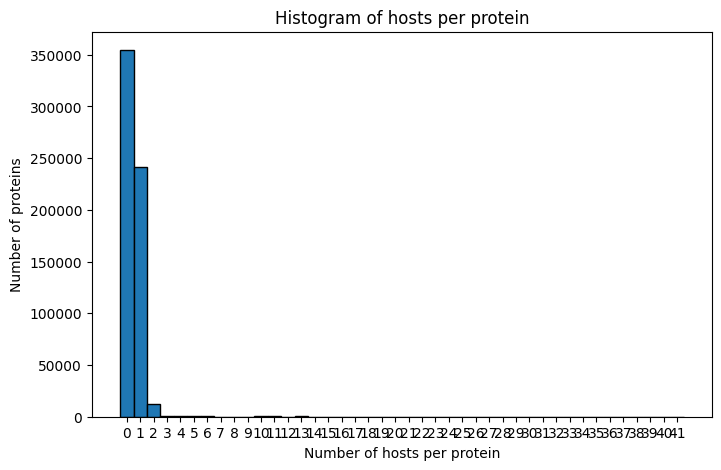

In [31]:
# Compute number of hosts per protein
df['num_hosts'] = df['uniprot_host_tax_ids'].str.len()

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df['num_hosts'], bins=range(0, df['num_hosts'].max() + 2), edgecolor='black', align='left')
plt.xlabel('Number of hosts per protein')
plt.ylabel('Number of proteins')
plt.title('Histogram of hosts per protein')
plt.xticks(range(0, df['num_hosts'].max() + 1))
plt.show()

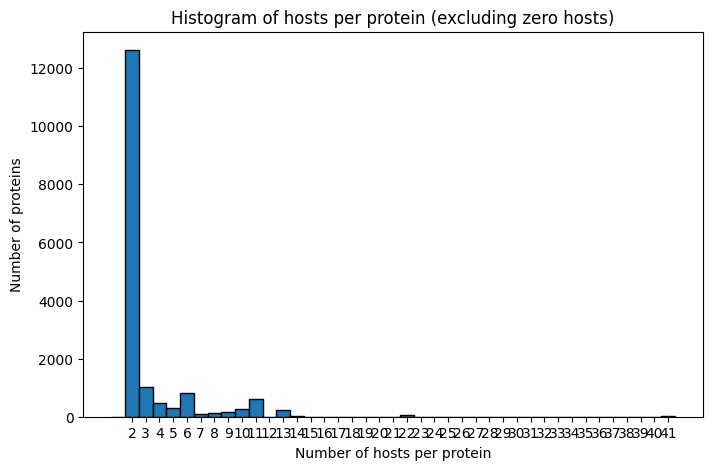

In [32]:
# Compute number of hosts per protein
df['num_hosts'] = df['uniprot_host_tax_ids'].str.len()

# Remove rows with zero or one hosts
df_multiple = df[df['num_hosts'] > 1]

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_multiple['num_hosts'], bins=range(1, df_multiple['num_hosts'].max() + 2), 
         edgecolor='black', align='left')
plt.xlabel('Number of hosts per protein')
plt.ylabel('Number of proteins')
plt.title('Histogram of hosts per protein (excluding zero hosts)')
plt.xticks(range(2, df_multiple['num_hosts'].max() + 1))
plt.show()


Top 20 host tax IDs for multi-label proteins:
    tax_id  count
0     9606  12716
1     9598  12351
2     9823   1394
3     9527   1309
4     9539    851
5    10090    833
6     9031    761
7     6937    675
8    85517    667
9   273792    667
10   41426    667
11    6938    659
12    9534    628
13    9520    626
14    9481    626
15    9536    624
16   69079    624
17    9940    615
18    7160    411
19    7159    392


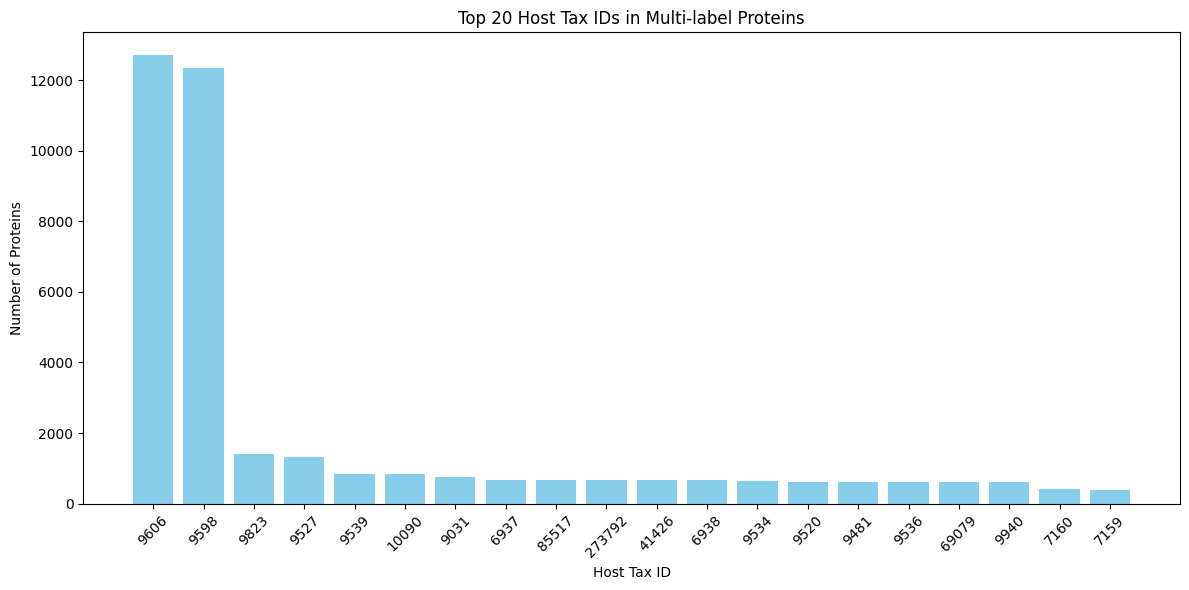

In [37]:
# Show the top 20 most common host tax IDs and their counts for multi-label proteins
top_hosts = df_multiple['uniprot_host_tax_ids'].explode().value_counts().head(20)
top_hosts_df = pd.DataFrame(top_hosts).reset_index()
top_hosts_df.columns = ['tax_id', 'count']
print("Top 20 host tax IDs for multi-label proteins:")
print(top_hosts_df)

# Plot bar chart of top 20 host tax IDs
plt.figure(figsize=(12,6))
plt.bar(top_hosts_df['tax_id'].astype(str), top_hosts_df['count'], color='skyblue')
plt.xlabel('Host Tax ID')
plt.ylabel('Number of Proteins')
plt.title('Top 20 Host Tax IDs in Multi-label Proteins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Number of unique host tax IDs in multi-label proteins
unique_hosts_multi = set()
for host_list in df_multiple['uniprot_host_tax_ids']:
    unique_hosts_multi.update(host_list)
print(f"Number of unique host tax IDs in multi-label proteins: {len(unique_hosts_multi)}")

# Top 10 most frequent host combinations (multi-label only)
host_combinations = df_multiple['uniprot_host_tax_ids'].apply(lambda x: tuple(sorted(x)))
comb_counter = Counter(host_combinations)
top_combinations = comb_counter.most_common(10)
print("Top 10 most frequent host combinations (multi-label proteins):")
for comb, count in top_combinations:
    print(f"{comb}: {count}")

Number of unique host tax IDs in multi-label proteins: 504
Top 10 most frequent host combinations (multi-label proteins):
(9598, 9606): 10219
(9527, 9598): 1309
(6937, 6938, 9823, 41426, 85517, 273792): 659
(9031, 9481, 9520, 9534, 9536, 9539, 9598, 9606, 9823, 10090, 69079): 624
(9606, 9925, 9940): 321
(7158, 8495, 8782, 9606, 9796, 9940, 34610, 34627, 34630, 34861, 53527, 308735, 308737): 241
(9606, 10112, 10114): 238
(7159, 7160, 9544, 9606): 202
(7159, 7160, 9533, 9539, 9554, 9573, 9598, 9606, 188700, 299627): 185
(8501, 8502, 184234): 167
